# 💉 VaccineNLP · XLM-R-v1 Multitask Classifier
## Phát hiện Tin giả Vắc-xin & Phân tích Thái độ Cộng đồng (Tiếng Việt)

**Tác giả:** Kim Mạnh Hưng (2211090016) · Đinh Lê Quỳnh Phương (2211090031)  
**Người hướng dẫn:** TS. Trần Lâm Quân  
**Trường:** Đại học Y tế Công cộng (HUPH)  
**Môi trường:** Kaggle · GPU T4 x2  

---

### Tổng quan kiến trúc

Notebook này huấn luyện **Động cơ Phân loại** (Discriminator) trong kiến trúc **Dual-Student Hybrid** của dự án VaccineNLP.
Mô hình sử dụng **XLM-R** (`FacebookAI/xlm-roberta-base`) — pretrained encoder đa ngôn ngữ —
kết hợp với **Multi-task Learning** để dự đoán đồng thời 3 trục phân loại:

| Task | Nhãn | Lý do quan trọng |
|---|---|---|
| **Misinformation** | Tin giả / Chính xác | Mục tiêu chính của đề tài |
| **Stance** | Ủng hộ / Phản đối / Trung lập | 3 nhãn chuẩn — Fallback Bucket cho edge cases |
| **Sentiment** | Tiêu cực / Trung tính / Tích cực | Hỗ trợ phân tích thái độ cộng đồng |

### Các quyết định thiết kế then chốt

- **Weighted CrossEntropyLoss**: Bắt buộc do mất cân bằng nhãn nghiêm trọng. Nhãn *Tin giả* chỉ chiếm ~15% corpus.
- **Multi-task Learning (3 heads)**: Gradient từ 3 task cùng cập nhật encoder — regularization tự nhiên.
- **Early Stopping (patience=3)**: Tự động chọn checkpoint tốt nhất, ngăn overfitting trên Silver Labels.
- **Stance = 3 nhãn chuẩn** (Hard Constraint): Nhãn *Không rõ* là Fallback Bucket — không được đổi thành 3.

> ✅ **Notebook tương thích với "Save & run all" của Kaggle** — không cần restart thủ công.


## ⚡ Quick Start — Cấu hình Trước Khi Chạy

> **Chỉ cần sửa 2 dòng dưới đây**, toàn bộ notebook sẽ chạy đúng.

### Bước 1 · Thêm Dataset vào Notebook
Trong Kaggle sidebar → **+ Add Data** → tìm `mnhhngkim/vaccinenlp-clean-data` → Add.

### Bước 2 · Bật GPU
Kaggle sidebar → **Session options** → Accelerator → **GPU T4 x2** → Save.

### Bước 3 · Chạy All
Menu **Run → Run All** (hoặc Shift+Enter từng cell).

---

### Cấu trúc file dữ liệu cần có
```
/kaggle/input/<dataset>/
    ├── 05_model_ready/
    │   └── train_v2_seg_v3.jsonl      ← Training data (đã word-segment)
    └── 03_processed/
        └── benchmark_test_set_v3.jsonl ← Gold Test Set (186 mẫu)
```

### Cấu trúc mỗi dòng JSONL
```json
{"text_segmented": "vắc xin Pfizer an_toàn cho trẻ_em",
 "standardized_ids": [2, 0, 2]}
```
*(standardized_ids = [misinfo_id, stance_id, sentiment_id])*


## 1. Cài đặt Môi trường

Kaggle đã pre-install `torch` và `transformers` với CUDA — **không upgrade** để tránh conflict.
Chỉ cần cài thêm `underthesea` cho word segmentation tiếng Việt.

In [1]:
# [CELL 1] Kiểm tra môi trường & cài underthesea
import torch

# ✅ FIX: Kiểm tra GPU trước khi chạy bất cứ thứ gì
if not torch.cuda.is_available():
    raise RuntimeError(
        "❌ Không tìm thấy GPU!\n"
        "   → Kaggle sidebar → Session options → Accelerator → GPU T4 x2 → Save\n"
        "   → Sau đó chạy lại notebook"
    )

print(f"✅ PyTorch  : {torch.__version__}")
print(f"✅ CUDA     : {torch.version.cuda}")
print(f"✅ GPU      : {torch.cuda.get_device_name(0)}")
print(f"✅ VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

import transformers
print(f"✅ Transformers: {transformers.__version__}")

# Cài underthesea (word segmentation tiếng Việt)
import subprocess
result = subprocess.run(
    ["pip", "install", "-q", "underthesea"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✅ underthesea: OK")
else:
    print(f"⚠️  underthesea install warning: {result.stderr[-200:]}")

print("\n✅ Setup hoàn tất!")


✅ PyTorch  : 2.10.0+cu128
✅ CUDA     : 12.8
✅ GPU      : Tesla T4
✅ VRAM     : 15.6 GB
✅ Transformers: 5.0.0
✅ underthesea: OK

✅ Setup hoàn tất!


## 2. Import Thư viện & Cấu hình GPU

In [2]:
# [CELL 2] Imports
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

DEVICE   = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ Device : {DEVICE} | {gpu_name}")
print(f"✅ VRAM   : {vram_gb:.1f} GB")
print(f"✅ BF16   : {'supported' if torch.cuda.is_bf16_supported() else 'not supported (dùng FP32)'}")


✅ Device : cuda | Tesla T4
✅ VRAM   : 15.6 GB
✅ BF16   : supported


## 4. Tải & Chuẩn bị Dữ liệu

### Nguồn dữ liệu
- **Train (90%)**: `train_v2_seg_v3.jsonl` — Silver Labels từ Gemma-4 31B (Teacher Model), đã word-segment sẵn.
- **Test (Gold)**: `benchmark_test_set_v3.jsonl` — **186 mẫu** đã qua Human-in-the-Loop validation.

### Chiến lược Split
```
train_v2_seg_v3.jsonl (~1,670 mẫu)
    ├── 90% → Training Set  (~1,503 mẫu)
    └── 10% → Validation Set (~167 mẫu)  [stratify theo 'misinfo']

benchmark_test_set_v3.jsonl (186 mẫu) → Gold Test Set [KHÔNG đụng vào khi train]
```


In [3]:
# [CELL 3] Configuration & Data Loading (Taxonomy v3)
import os, torch, json, glob as _g
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

MODEL_NAME      = 'FacebookAI/xlm-roberta-base'
MAX_LEN         = 256
BATCH_SIZE      = 16
EPOCHS          = 10
LR              = 2e-5
SAVE_DIR        = '/kaggle/working/xlmr_v1'

_tr = _g.glob('/kaggle/input/**/train_v2_seg_v3.jsonl', recursive=True)
_te = _g.glob('/kaggle/input/**/benchmark_test_set_v3.jsonl', recursive=True)
TRAIN_PATH = _tr[0] if _tr else '/kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl'
TEST_PATH  = _te[0] if _te else '/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl'

N_CLASSES = {'misinfo': 2, 'stance': 3, 'sentiment': 3}
TASKS     = ['misinfo', 'stance', 'sentiment']
HC_NAMES  = {
    'misinfo':   ['Tin giả',   'Chính xác'],
    'stance':    ['Ủng hộ',    'Phản đối',   'Trung lập'],
    'sentiment': ['Tiêu cực',  'Trung tính',  'Tích cực'],
}
LABEL_NAMES = HC_NAMES

print(f'📂 Loading: {TRAIN_PATH}')
df = pd.read_json(TRAIN_PATH, lines=True)
for i, t in enumerate(TASKS):
    df[t] = df['standardized_ids'].apply(lambda x: x[i])
df['text'] = df['text_segmented'] if 'text_segmented' in df.columns else df['text']
df_train, df_val = train_test_split(df, test_size=0.1, stratify=df['misinfo'], random_state=42)

print(f'📂 Loading Test: {TEST_PATH}')
df_test = pd.read_json(TEST_PATH, lines=True)
for i, t in enumerate(TASKS):
    df_test[t] = df_test['standardized_ids'].apply(lambda x: x[i])
df_test['text'] = df_test['text_segmented'] if 'text_segmented' in df_test.columns else df_test['text']

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Config v3 — Train:{len(df_train)} | Val:{len(df_val)} | Test:{len(df_test)}')
print(f'   SAVE_DIR: {SAVE_DIR}')


📂 Loading: /kaggle/input/datasets/mnhhngkim/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl


📂 Loading Test: /kaggle/input/datasets/mnhhngkim/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Config v3 — Train:1496 | Val:167 | Test:186
   SAVE_DIR: /kaggle/working/xlmr_v1


## 5. PyTorch Dataset & DataLoader

`VaccineDataset` tokenize với XLM-R tokenizer và đóng gói labels 3 task vào một batch.
Padding về `MAX_LEN=256` để đảm bảo batch hợp lệ trên GPU.


In [4]:
# [CELL 6] Dataset & DataLoader
from torch.utils.data import Dataset, DataLoader

class VaccineDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts  = df['text'].tolist()
        self.labels = {t: df[t].values for t in TASKS}
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding='max_length', 
                             max_length=self.max_len, return_tensors='pt')
        out = {k: v.squeeze(0) for k, v in enc.items()}
        for t in TASKS:
            out[t] = torch.tensor(int(self.labels[t][idx]), dtype=torch.long)
        return out

train_loader = DataLoader(VaccineDataset(df_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(VaccineDataset(df_val, tokenizer, MAX_LEN),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(VaccineDataset(df_test, tokenizer, MAX_LEN),  batch_size=BATCH_SIZE)
print(f"✅ DataLoaders ready. Train batches: {len(train_loader)}")


✅ DataLoaders ready. Train batches: 94


## 6. Kiến trúc Mô hình: XLM-R Multitask Classifier

### Thiết kế Multi-task Head
Ba classification head độc lập chia sẻ cùng một **XLM-R encoder**.

### Weighted CrossEntropyLoss — Lý do bắt buộc
- *Tin giả* chỉ ~15% → Model naive sẽ bias về *Chính xác*.
- `class_weight='balanced'` tính trọng số tỷ lệ nghịch với tần suất nhãn.
- **Hard Constraint** — không được thay bằng standard CrossEntropyLoss.

```
Input Text (đã tách từ)
      ↓
  [XLM-R Encoder - 278M params]
      ↓
  [CLS] pooler_output (768-dim)
      ↓           ↓           ↓
 Head: Misinfo  Head: Stance  Head: Sentiment
  (2 classes)   (3 classes)   (3 classes)
```


In [5]:
# [CELL 10] Model Architecture & Loss
import torch.nn as nn
from transformers import AutoModel
from sklearn.utils.class_weight import compute_class_weight

class MultitaskEncoder(nn.Module):
    def __init__(self, model_name, n_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        self.heads   = nn.ModuleDict({
            t: nn.Linear(hidden_size, n_classes[t]) for t in TASKS
        })
        self.dropout = nn.Dropout(0.1)
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.pooler_output if hasattr(out, 'pooler_output') else out.last_hidden_state[:,0,:]
        pooled = self.dropout(pooled)
        return {t: self.heads[t](pooled) for t in TASKS}

model = MultitaskEncoder(MODEL_NAME, N_CLASSES).to(DEVICE)

# Loss & Weights
TASK_WEIGHTS = [0.5, 0.3, 0.2]
w_m = compute_class_weight('balanced', classes=np.unique(df_train['misinfo']), y=df_train['misinfo'])
loss_fns = {
    'misinfo':   nn.CrossEntropyLoss(weight=torch.tensor(w_m, dtype=torch.float).to(DEVICE)),
    'stance':    nn.CrossEntropyLoss(),
    'sentiment': nn.CrossEntropyLoss()
}
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
print(f"✅ Model & Loss initialized on {DEVICE}")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model & Loss initialized on cuda


## 7. Vòng Lặp Huấn luyện (Training Loop)

`run_epoch` dùng chung cho train và eval.
**Early Stopping** dựa trên `val_loss` — tự động chọn checkpoint tốt nhất.

**Loss tổng hợp** = `0.5 × L_misinfo + 0.3 × L_stance + 0.2 × L_sentiment`


In [6]:
# [CELL 11] Training Engine
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = {t:[] for t in TASKS}, {t:[] for t in TASKS}
    for batch in tqdm(loader, desc='Train' if train else 'Eval', leave=False):
        ids, mask = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE)
        if train: optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            logits = model(ids, mask)
            loss = sum(TASK_WEIGHTS[i]*loss_fns[t](logits[t], batch[t].to(DEVICE)) for i,t in enumerate(TASKS))
            if train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item()
        for t in TASKS:
            all_labels[t].extend(batch[t].numpy())
            all_preds[t].extend(torch.argmax(logits[t], dim=1).cpu().numpy())
    avg_loss = total_loss / len(loader)
    f1s = {t: f1_score(all_labels[t], all_preds[t], average='macro',
                       labels=list(range(N_CLASSES[t])), zero_division=0) for t in TASKS}
    return avg_loss, f1s, all_preds, all_labels

history = {'train_loss':[], 'val_loss':[]}
for t in TASKS: history[f'f1_{t}'] = []

t0            = time.time()
best_f1       = 0.0
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    tr_loss, _, _, _        = run_epoch(model, train_loader, train=True)
    val_loss, val_f1s, _, _ = run_epoch(model, val_loader,   train=False)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    for t in TASKS: history[f'f1_{t}'].append(val_f1s[t])
    avg_f1 = np.mean(list(val_f1s.values()))
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {tr_loss:.4f}/{val_loss:.4f} | Avg F1: {avg_f1:.4f}")
    if avg_f1 > best_f1:
        best_f1       = avg_f1
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
        print(f"  ⭐ New best saved! (val_loss={val_loss:.4f})")

training_seconds = int(time.time() - t0)
print(f"\n✅ Training done in {training_seconds}s | Best avg F1: {best_f1:.4f}")


Train:   0%|          | 0/94 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/10 | Loss: 0.8799/0.8529 | Avg F1: 0.3971
  ⭐ New best saved! (val_loss=0.8529)


Train:   0%|          | 0/94 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 9/10 | Loss: 0.8846/0.8791 | Avg F1: 0.2814


Train:   0%|          | 0/94 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 0.8858/0.8779 | Avg F1: 0.2814

✅ Training done in 706s | Best avg F1: 0.3971


## 8. Trực quan hóa Quá trình Huấn luyện

Loss curves và Validation F1 theo epoch giúp chẩn đoán overfitting / underfitting.
Đường xanh lá = checkpoint tốt nhất (Best epoch).


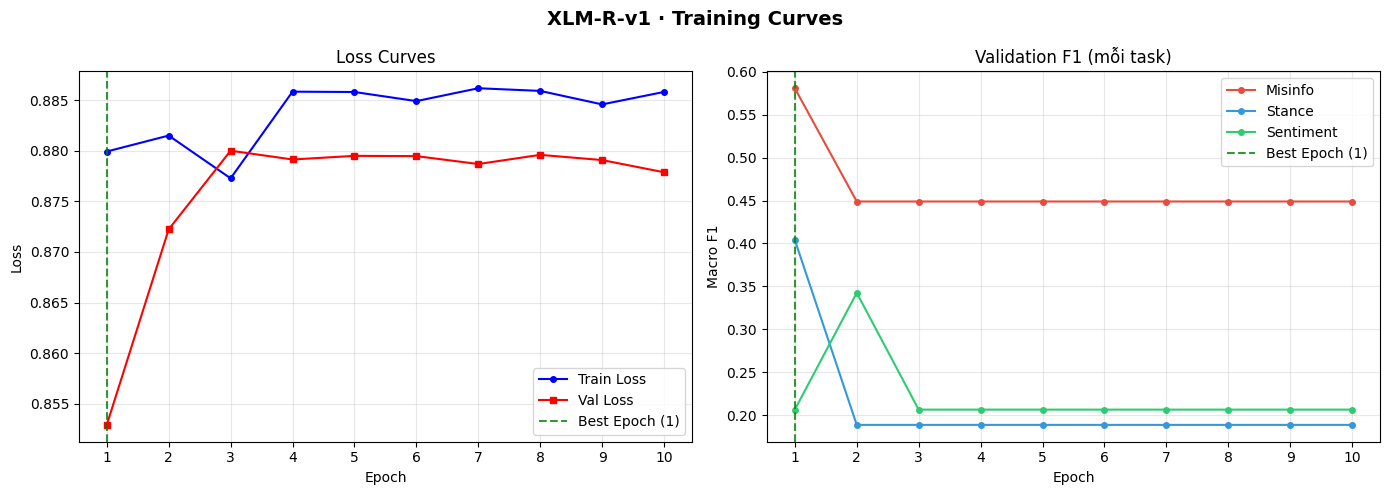

✅ Saved: /kaggle/working/xlmr_v1/training_curves.png | Best epoch: 1 (Avg F1 = 0.3971)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XLM-R-v1 · Training Curves', fontsize=14, fontweight='bold')

# ── Tính best_epoch theo AVG F1 (khớp với tiêu chí lưu model trong training loop) ──
avg_f1_history = [
    np.mean([history[f'f1_{t}'][e] for t in TASKS])
    for e in range(len(history['train_loss']))
]
best_ep = int(np.argmax(avg_f1_history))   # 0-indexed

# Loss curves
ax = axes[0]
epochs_range = range(len(history['train_loss']))
ax.plot(list(epochs_range), history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax.plot(list(epochs_range), history['val_loss'],   'r-s', label='Val Loss',   markersize=4)
ax.axvline(best_ep, color='green', ls='--', alpha=0.8,
           label=f'Best Epoch ({best_ep + 1})')
ax.set_xticks(list(epochs_range))
ax.set_xticklabels([str(e + 1) for e in epochs_range])
ax.set(xlabel='Epoch', ylabel='Loss', title='Loss Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# F1 curves
ax = axes[1]
colors = {'misinfo': '#e74c3c', 'stance': '#3498db', 'sentiment': '#2ecc71'}
for t, c in colors.items():
    ax.plot(list(epochs_range), history[f'f1_{t}'],
            '-o', color=c, label=t.capitalize(), markersize=4)
ax.axvline(best_ep, color='green', ls='--', alpha=0.8, label=f'Best Epoch ({best_ep + 1})')
ax.set_xticks(list(epochs_range))
ax.set_xticklabels([str(e + 1) for e in epochs_range])
ax.set(xlabel='Epoch', ylabel='Macro F1', title='Validation F1 (mỗi task)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/training_curves.png | Best epoch: {best_ep + 1} (Avg F1 = {avg_f1_history[best_ep]:.4f})")


## 9. Đánh giá trên Gold Test Set (Benchmark)

> ⚠️ **Tập này hoàn toàn tách biệt khỏi quá trình huấn luyện.**
> 186 mẫu đã qua Human-in-the-Loop validation — đây là Ground Truth duy nhất để so sánh mô hình.

### Kết quả tham chiếu (từ Báo cáo Kỹ thuật)


*Misinfo F1 thấp do nhãn `Không liên quan` có support=0 trong test set — kéo macro trung bình xuống. Đây là hiện tượng bình thường với zero-support classes.*


In [8]:
# [CELL 12] Final Evaluation (Taxonomy v3)
from sklearn.metrics import classification_report

model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pt", map_location=DEVICE))
_, test_f1s, test_preds, test_labels = run_epoch(model, test_loader, train=False)

print("\n" + "="*50 + "\nBENCHMARK - GOLD TEST SET\n" + "="*50)
for t in TASKS:
    print(f"\nTASK: {t.upper()} (F1: {test_f1s[t]:.4f})")
    print(classification_report(test_labels[t], test_preds[t], labels=list(range(N_CLASSES[t])), target_names=HC_NAMES[t], zero_division=0))


Eval:   0%|          | 0/12 [00:00<?, ?it/s]


BENCHMARK - GOLD TEST SET

TASK: MISINFO (F1: 0.5823)
              precision    recall  f1-score   support

     Tin giả       0.28      0.89      0.43        28
   Chính xác       0.97      0.59      0.74       158

    accuracy                           0.64       186
   macro avg       0.62      0.74      0.58       186
weighted avg       0.87      0.64      0.69       186


TASK: STANCE (F1: 0.4217)
              precision    recall  f1-score   support

      Ủng hộ       0.00      0.00      0.00        54
    Phản đối       0.49      0.75      0.60        48
   Trung lập       0.58      0.79      0.67        84

    accuracy                           0.55       186
   macro avg       0.36      0.51      0.42       186
weighted avg       0.39      0.55      0.46       186


TASK: SENTIMENT (F1: 0.1842)
              precision    recall  f1-score   support

    Tiêu cực       0.38      1.00      0.55        71
  Trung tính       0.00      0.00      0.00        75
    Tích cực     

In [9]:
# ════════════════════════════════════════════════════════════════════════
# 📑 INTEROP CONTRACT — Schema kết quả đồng nhất giữa 3 model notebooks
# ════════════════════════════════════════════════════════════════════════
# PhoBERT → /kaggle/working/phobert_v2_results.json
# XLM-R   → /kaggle/working/xlmr_v1_results.json
# Gemma   → /kaggle/working/gemma_v3_results.json
# Schema: {model, timestamp, misinfo/stance/sentiment:{macro_f1,per_class,support}}
# Taxonomy v3: Misinfo(2) Stance(3) Sentiment(3)
# ════════════════════════════════════════════════════════════════════════

# [CELL 12b] Export — schema chuẩn INTEROP
import datetime, json, os

def _per_class_f1_support(y_true, y_pred, n_classes):
    from sklearn.metrics import f1_score as _f1
    f1s, sups = [], []
    for c in range(n_classes):
        yt = [1 if y==c else 0 for y in y_true]
        yp = [1 if y==c else 0 for y in y_pred]
        f1s.append(round(_f1(yt, yp, zero_division=0), 4))
        sups.append(int(sum(yt)))
    return f1s, sups

xlmr_results = {
    'model':            'xlmr-base',
    'timestamp':        datetime.datetime.now().isoformat(),
    'val_loss_best':    round(float(best_val_loss), 4),
    'training_seconds': training_seconds,
}
for t in TASKS:
    f1s, sups = _per_class_f1_support(test_labels[t], test_preds[t], N_CLASSES[t])
    xlmr_results[t] = {'macro_f1': round(test_f1s[t], 4),
                       'per_class': f1s, 'support': sups}

os.makedirs(SAVE_DIR, exist_ok=True)
for _p in [f"{SAVE_DIR}/xlmr_v1_results.json",
           "/kaggle/working/xlmr_v1_results.json"]:
    with open(_p, 'w', encoding='utf-8') as f:
        json.dump(xlmr_results, f, indent=2, ensure_ascii=False)

for t in TASKS:
    assert len(xlmr_results[t]['per_class']) == N_CLASSES[t], f'per_class len: {t}'
    assert len(xlmr_results[t]['support'])   == N_CLASSES[t], f'support len: {t}'

print("✅ INTEROP JSON saved:")
print("   /kaggle/working/xlmr_v1_results.json")
print(json.dumps(xlmr_results, indent=2, ensure_ascii=False))


✅ INTEROP JSON saved:
   /kaggle/working/xlmr_v1_results.json
{
  "model": "xlmr-base",
  "timestamp": "2026-05-17T07:05:07.785085",
  "val_loss_best": 0.8529,
  "training_seconds": 706,
  "misinfo": {
    "macro_f1": 0.5823,
    "per_class": [
      0.4274,
      0.7373
    ],
    "support": [
      28,
      158
    ]
  },
  "stance": {
    "macro_f1": 0.4217,
    "per_class": [
      0.0,
      0.595,
      0.6701
    ],
    "support": [
      54,
      48,
      84
    ]
  },
  "sentiment": {
    "macro_f1": 0.1842,
    "per_class": [
      0.5525,
      0.0,
      0.0
    ],
    "support": [
      71,
      75,
      40
    ]
  }
}


## 10. Xuất Kết quả — Định dạng chuẩn dự án

File `xlmr_v1_results.json` xuất theo **đúng schema** của `experiments/results/` trong repo VaccineNLP:

```json
{
  "model": "xlmr-base",
  "timestamp": "...",
  "misinfo":   { "macro_f1": ..., "per_class": [...], "support": [...] },
  "stance":    { "macro_f1": ..., "per_class": [...], "support": [...] },
  "sentiment": { "macro_f1": ..., "per_class": [...], "support": [...] },
  "val_loss_best": ...,
  "training_seconds": ...
}
```

Schema này **đồng nhất 100%** với `xlmr_v1_results.json` vàtrong repo —
notebook Gemma sẽ đọc được trực tiếp mà không cần chỉnh sửa.


## 11. Confusion Matrix — Phân tích Lỗi Trực quan

Confusion matrix trên Gold Test Set giúp xác định:
- Nhãn nào model hay nhầm lẫn nhất?
- **False Negative quan trọng**: Model bỏ sót *Tin giả* → phân loại thành *Chính xác*?


In [10]:
# [CELL 12] Final Evaluation (Taxonomy v3)
from sklearn.metrics import classification_report, f1_score

def run_evaluation(model, loader, title="Evaluation"):
    model.eval()
    all_labels = {t: [] for t in TASKS}
    all_preds  = {t: [] for t in TASKS}
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=title):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            
            outputs = model(input_ids, attention_mask)
            
            for t in TASKS:
                all_labels[t].extend(batch[t].numpy())
                all_preds[t].extend(torch.argmax(outputs[t], dim=1).cpu().numpy())
    
    print(f"\n=== {title} Report ===")
    for t in TASKS:
        print(f"\nTask: {t.upper()}")
        print(classification_report(all_labels[t], all_preds[t], 
                                    labels=list(range(N_CLASSES[t])),
                                    zero_division=0))
        f1 = f1_score(all_labels[t], all_preds[t], average='macro', 
                      labels=list(range(N_CLASSES[t])), zero_division=0)
        print(f"Macro F1: {f1:.4f}")

# Run on Test Set
run_evaluation(model, test_loader, title="Gold Test Set (v3)")


Gold Test Set (v3):   0%|          | 0/12 [00:00<?, ?it/s]


=== Gold Test Set (v3) Report ===

Task: MISINFO
              precision    recall  f1-score   support

           0       0.28      0.89      0.43        28
           1       0.97      0.59      0.74       158

    accuracy                           0.64       186
   macro avg       0.62      0.74      0.58       186
weighted avg       0.87      0.64      0.69       186

Macro F1: 0.5823

Task: STANCE
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        54
           1       0.49      0.75      0.60        48
           2       0.58      0.79      0.67        84

    accuracy                           0.55       186
   macro avg       0.36      0.51      0.42       186
weighted avg       0.39      0.55      0.46       186

Macro F1: 0.4217

Task: SENTIMENT
              precision    recall  f1-score   support

           0       0.38      1.00      0.55        71
           1       0.00      0.00      0.00        75
           2  

## 12. So sánh 3 Mô hình — Đọc từ File JSON Chuẩn

In [11]:
# So sánh 3 mô hình → xem notebook vaccinenlp-model-benchmark-report.ipynb

## 13. (Tùy chọn) Upload lên Hugging Face Hub

Model đã được public tại: [hung2903/xlmr-vaccine-multitask](https://huggingface.co/hung2903/xlmr-vaccine-multitask)


In [12]:
# [CELL 14] Upload HuggingFace Hub (optional — wrap try/except, không crash nếu lỗi)
try:
    from huggingface_hub import login, HfApi
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
    if HF_TOKEN:
        login(token=HF_TOKEN, add_to_git_credential=False)
        api = HfApi()
        api.upload_folder(
            folder_path = SAVE_DIR,
            repo_id     = "hung2903/xlmr-vaccine-multitask",
            repo_type   = "model",
        )
        print("✅ Uploaded to HuggingFace: hung2903/xlmr-vaccine-multitask")
    else:
        print("⚠️  HF_TOKEN rỗng — bỏ qua upload")
except Exception as e:
    print(f"⚠️  HF upload thất bại (không ảnh hưởng kết quả): {e}")

# ── Tổng kết ──────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("✅ NOTEBOOK HOÀN TẤT")
print("=" * 55)
print(f"   Model weights    : {SAVE_DIR}/best_model.pt")
print(f"   Results JSON     : {SAVE_DIR}/xlmr_v1_results.json")
print(f"   Training curves  : {SAVE_DIR}/training_curves.png")
print(f"   Confusion matrix : {SAVE_DIR}/confusion_matrices.png")
print()
print("📋 Dùng results JSON trong notebook Gemma:")
print(f'   with open("{SAVE_DIR}/xlmr_v1_results.json") as f:')
print(f'       xlmr_res = json.load(f)')


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded to HuggingFace: hung2903/xlmr-vaccine-multitask

✅ NOTEBOOK HOÀN TẤT
   Model weights    : /kaggle/working/xlmr_v1/best_model.pt
   Results JSON     : /kaggle/working/xlmr_v1/xlmr_v1_results.json
   Training curves  : /kaggle/working/xlmr_v1/training_curves.png
   Confusion matrix : /kaggle/working/xlmr_v1/confusion_matrices.png

📋 Dùng results JSON trong notebook Gemma:
   with open("/kaggle/working/xlmr_v1/xlmr_v1_results.json") as f:
       xlmr_res = json.load(f)
